In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
titanic =sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
features=["pclass","fare","sex","embarked","age"]
target=["survived"]

In [ ]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])


In [ ]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
titanic.shape

(891, 15)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [ ]:
X=titanic[features]
y=titanic[target]

In [ ]:
X.head()

,pclass,fare,sex,embarked,age
0,3,7.2500,1,2,22.0
1,1,71.2833,0,0,38.0
2,3,7.9250,0,2,26.0
3,1,53.1000,0,2,35.0
4,3,8.0500,1,2,35.0


In [ ]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_test.head()

,pclass,fare,sex,embarked,age
709,3,15.2458,1,0,28.0
439,2,10.5000,1,2,31.0
840,3,7.9250,1,2,20.0
720,2,33.0000,0,2,6.0
39,3,11.2417,0,0,14.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=dt.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Confusion Matrix : ",confusion_matrix(y_test,y_pred))
print("Classification Report :",classification_report(y_test,y_pred))

Accuracy Score :  0.7653631284916201
Confusion Matrix :  [[82 23]
 [19 55]]
Classification Report :               precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



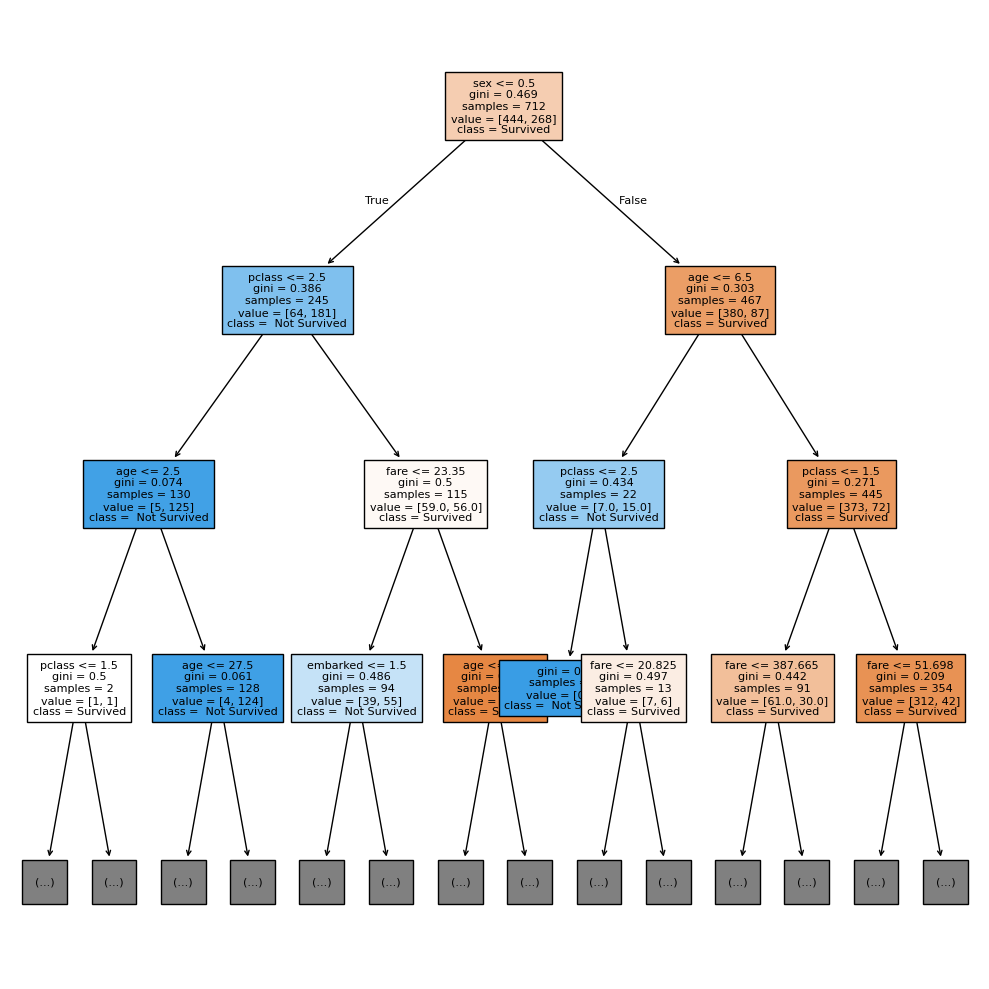

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dt,
          filled=True,
          feature_names=features,
          class_names=["Survived"," Not Survived"],
          max_depth=3,
          fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
X.head()

,pclass,fare,sex,embarked,age
0,3,7.2500,1,2,22.0
1,1,71.2833,0,0,38.0
2,3,7.9250,0,2,26.0
3,1,53.1000,0,2,35.0
4,3,8.0500,1,2,35.0


In [ ]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [ ]:
#this above decision tree was applied without prunning

In [ ]:
#Now we will implement the decision tree using prunning

#Decision Tree With Pre Prunning

Max Depth :  2
Accuracy :  76.53631284916202
Max Depth :  3
Accuracy :  79.88826815642457
Max Depth :  4
Accuracy :  79.88826815642457


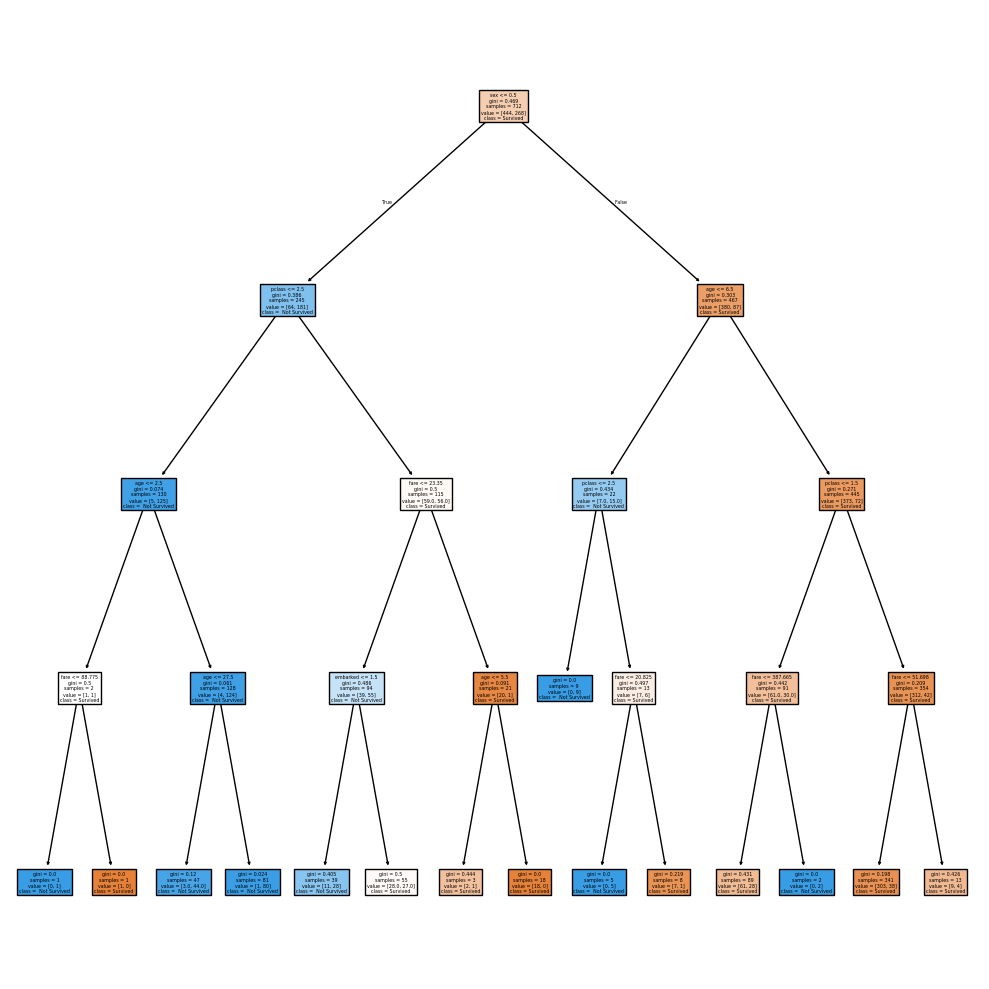

Max Depth :  5
Accuracy :  79.88826815642457
Max Depth :  6
Accuracy :  79.88826815642457
Max Depth :  7
Accuracy :  79.88826815642457
Max Depth :  8
Accuracy :  78.2122905027933
Max Depth :  9
Accuracy :  79.3296089385475
Max Depth :  10
Accuracy :  79.3296089385475


In [ ]:
max_depth=[2,3,4,5,6,7,8,9,10]
for  depth in max_depth:
  dt=DecisionTreeClassifier(max_depth=depth)
  dt.fit(X_train,y_train)
  acc=dt.score(X_test,y_test)
  print("Max Depth : ",depth)
  print("Accuracy : ",acc*100)
  if depth==4:
    plt.figure(figsize=(10,10))
    plot_tree(dt,
          filled=True,
          feature_names=features,
          class_names=["Survived"," Not Survived"],
          max_depth=depth,
         )
    plt.tight_layout()
    plt.show()



Min Sample Split  5
Accuracy :  79.88826815642457
Min Sample Split  10
Accuracy :  79.88826815642457
Min Sample Split  15
Accuracy :  79.88826815642457
Min Sample Split  20
Accuracy :  79.88826815642457


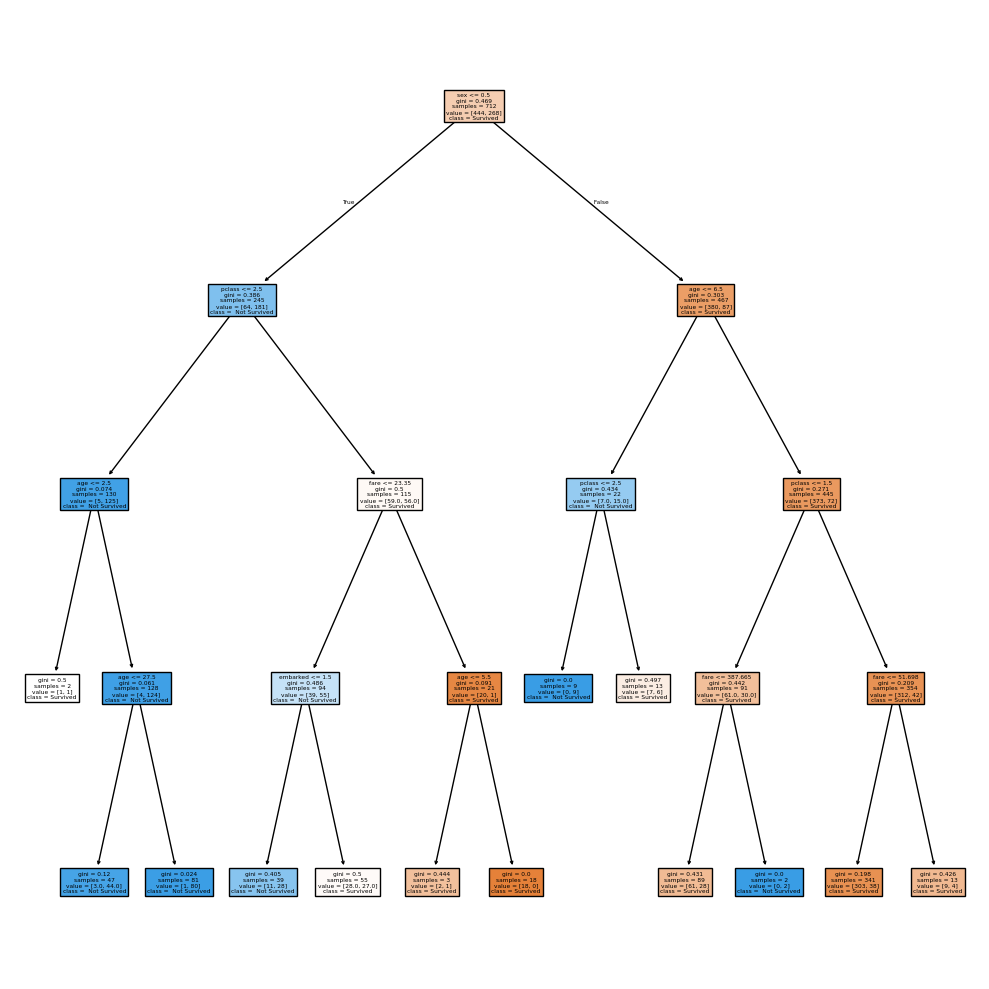

Min Sample Split  25
Accuracy :  79.3296089385475
Min Sample Split  30
Accuracy :  79.3296089385475


In [ ]:
min_samples_splits=[5,10,15,20,25,30]
for  split in min_samples_splits:
  model=DecisionTreeClassifier(max_depth=4,min_samples_split=split)
  model.fit(X_train,y_train)
  acc=model.score(X_test,y_test)
  print("Min Sample Split ",split)
  print("Accuracy : ",acc*100)
  if split==20:
    plt.figure(figsize=(10,10))
    plot_tree(model,
          filled=True,
          feature_names=features,
          class_names=["Survived"," Not Survived"],
          max_depth=4,
         )
    plt.tight_layout()
    plt.show()

#Decisison Tree with Post Prunnning

In [ ]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [ ]:
#Train our model for all alphas
tree=[]
for ccp_alpha in ccp_alphas:
  dt=DecisionTreeClassifier(random_state=42,ccp_alpha=ccp_alpha)
  dt.fit(X_train,y_train)
  acc=dt.score(X_test,y_test)
  tree.append((dt,ccp_alpha))
  print("Alpha : ",ccp_alpha)
  print("Accuracy : ",acc*100)

Alpha :  0.0
Accuracy :  77.09497206703911
Alpha :  0.0
Accuracy :  77.09497206703911
Alpha :  6.688068485821317e-05
Accuracy :  77.09497206703911
Alpha :  0.00014592149423610108
Accuracy :  77.09497206703911
Alpha :  0.0001844285552150735
Accuracy :  77.09497206703911
Alpha :  0.00020064205457463822
Accuracy :  77.09497206703911
Alpha :  0.00023408239700374524
Accuracy :  77.09497206703911
Alpha :  0.00023408239700374546
Accuracy :  77.09497206703911
Alpha :  0.00035112359550561797
Accuracy :  77.09497206703911
Alpha :  0.0004681647940074905
Accuracy :  77.09497206703911
Alpha :  0.0004681647940074905
Accuracy :  77.09497206703911
Alpha :  0.0005617977528089889
Accuracy :  77.09497206703911
Alpha :  0.0006242197253433206
Accuracy :  77.09497206703911
Alpha :  0.0006679912304741031
Accuracy :  77.09497206703911
Alpha :  0.0007022471910112359
Accuracy :  77.09497206703911
Alpha :  0.0007022471910112364
Accuracy :  77.09497206703911
Alpha :  0.0008192883895131084
Accuracy :  77.094972067

In [ ]:
best_acc = 0
best_alpha = 0.0

for dt_candidate, ccp_a_candidate in tree:
  curr_acc = dt_candidate.score(X_test, y_test)
  if curr_acc > best_acc:
    best_acc = curr_acc
    best_alpha = ccp_a_candidate

print("Best Accuracy : ", best_acc * 100)

Best Accuracy :  83.79888268156425


In [ ]:
best_alpha

np.float64(0.13777997649438206)

In [ ]:
best_acc

0.5865921787709497

In [ ]:
best_model=DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
best_model=best_model.fit(X_train,y_train)

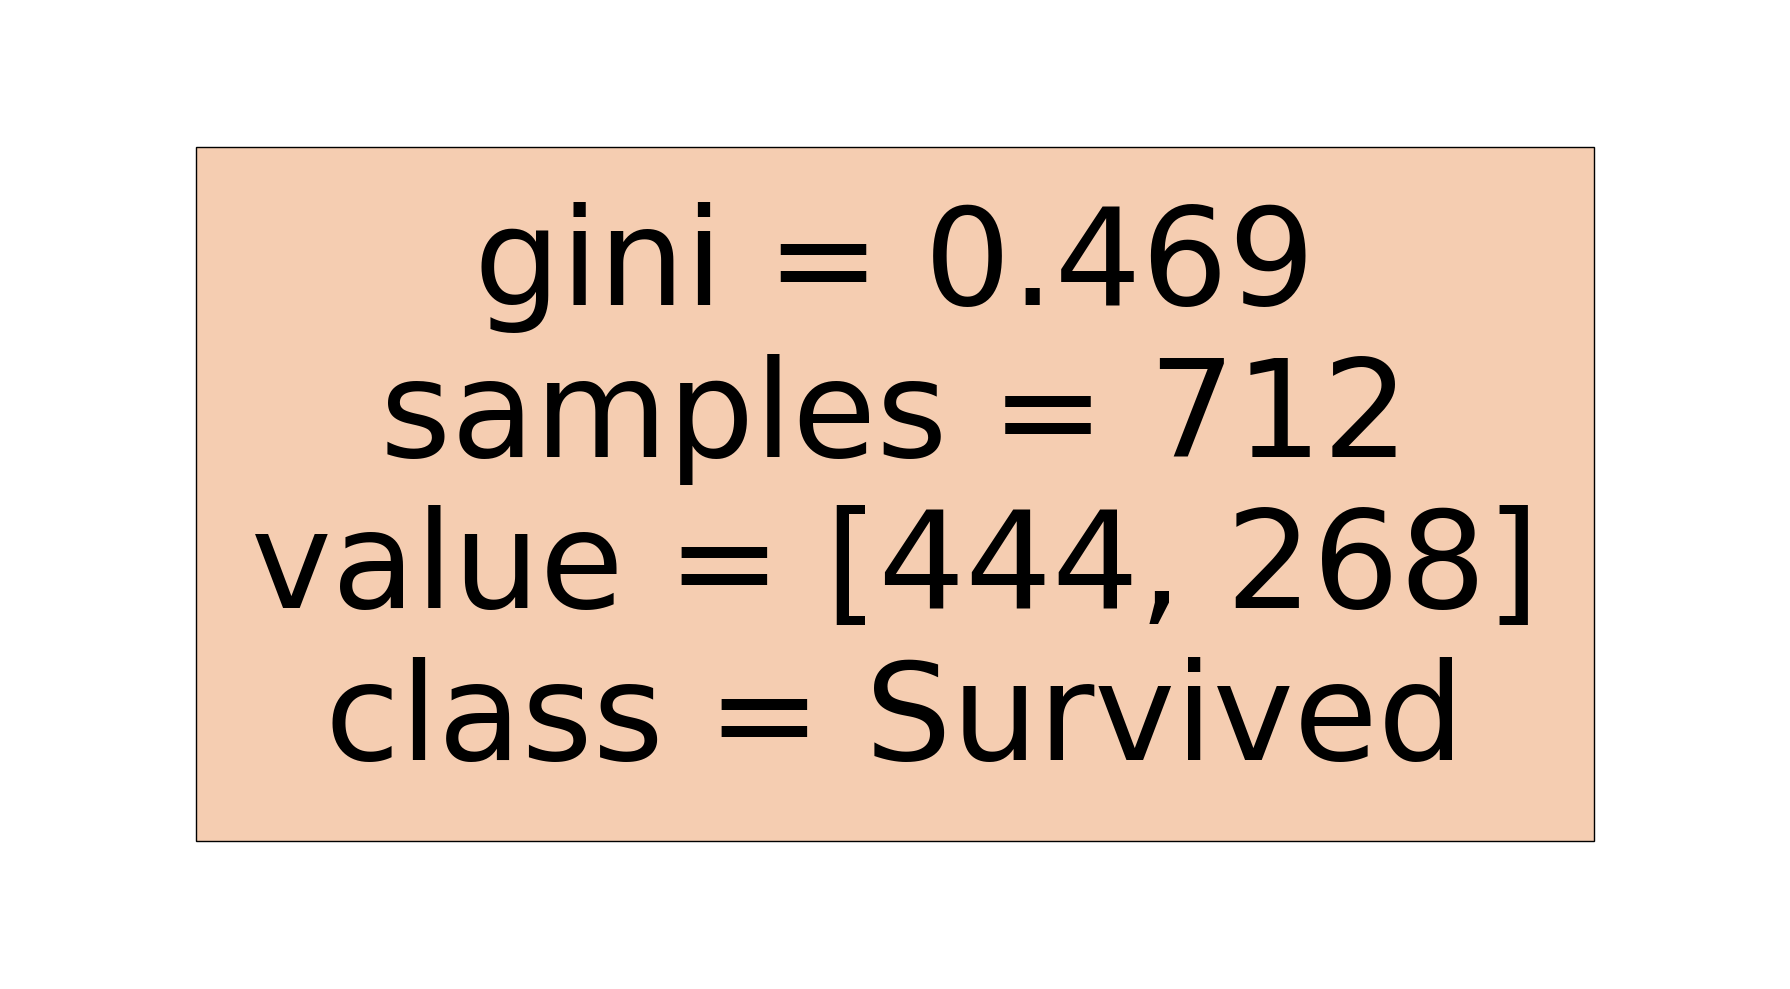

In [ ]:
# This one code is wrong
plt.figure(figsize=(18,10))
plot_tree(best_model,
          feature_names=features,
          class_names=["Survived"," Not Survived"],
          filled=True)
plt.tight_layout()
plt.show()